In [7]:
from sklearn.model_selection import train_test_split
import torch
import numpy as np

In [8]:
SCALE = 0.8

torch.manual_seed(42)

bubble_1 = torch.distributions.Normal(
    loc=torch.tensor([0.0, 0.0]),
    scale=torch.tensor([SCALE, SCALE])
)
bubble_2 = torch.distributions.Normal(
    loc=torch.tensor([2.0, 2.0]), scale=torch.tensor([SCALE, SCALE])
)
bubble_3 = torch.distributions.Normal(
    loc=torch.tensor([-2.0, -2.0]),
    scale=torch.tensor([SCALE, SCALE])
)
bubble_4 = torch.distributions.Normal(
    loc=torch.tensor([2.0, -2.0]),
    scale=torch.tensor([SCALE, SCALE])
)

X = torch.cat([
    bubble_1.sample((400,)),
    bubble_2.sample((400,)),
    bubble_3.sample((400,)),
    bubble_4.sample((400,))
], dim=0)   
y = torch.cat([
    torch.zeros(400, dtype=torch.long),
    torch.ones(400, dtype=torch.long),
    2 * torch.ones(400, dtype=torch.long),
    3 * torch.ones(400, dtype=torch.long)
], dim=0)


X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

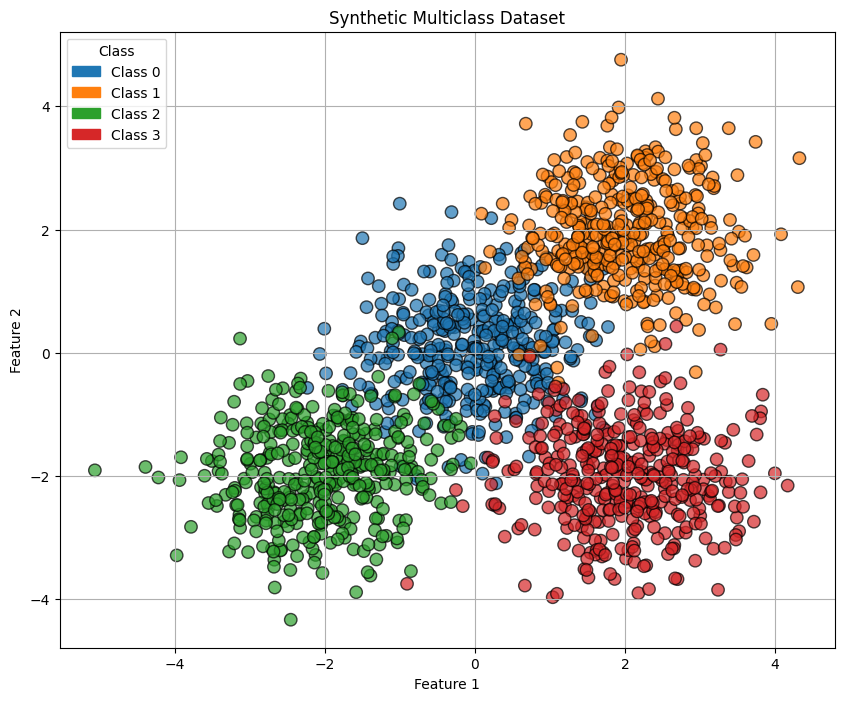

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Define specific colors for each class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
color_map = [colors[int(label)] for label in y.numpy()]

plt.scatter(
    x=X[:, 0].numpy(),
    y=X[:, 1].numpy(),
    c=color_map,
    s=80,
    alpha=0.7,
    edgecolor='k'
)
plt.title('Synthetic Multiclass Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Create custom legend
import matplotlib.patches as mpatches
legend_elements = [mpatches.Patch(color=colors[i], label=f'Class {i}') for i in range(4)]
plt.legend(handles=legend_elements, title='Class')
plt.grid()
plt.show()


In [10]:
from epiuc.uncertainty.classification import MLP_Classifier
from epiuc.uncertainty.wrapper import Ensemble_Classifier


nn = MLP_Classifier(
    input_shape=2,
    n_classes=4,
    n_layers=2,
    num_neurons=64,
    dropout_prob=0,
    random_state=42,
)

base_ensmble = Ensemble_Classifier(
    nn,
    n_models=20,
)
base_ensmble.compile()
base_ensmble.fit(X_train,y_train, n_epochs=40,batch_size=64)

Using MPS Device for training
Using fast routine


/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished Epoch 0 from 40 with 7651.26416015625
Finished Epoch 1 from 40 with 7109.4052734375
Finished Epoch 2 from 40 with 6733.5185546875
Finished Epoch 3 from 40 with 6437.29541015625
Finished Epoch 4 from 40 with 6191.3134765625
Finished Epoch 5 from 40 with 5979.86083984375
Finished Epoch 6 from 40 with 5793.5068359375
Finished Epoch 7 from 40 with 5626.2470703125
Finished Epoch 8 from 40 with 5474.0771484375
Finished Epoch 9 from 40 with 5334.2236328125
Finished Epoch 10 from 40 with 5204.68994140625
Finished Epoch 11 from 40 with 5083.9814453125
Finished Epoch 12 from 40 with 4970.9208984375
Finished Epoch 13 from 40 with 4864.55126953125
Finished Epoch 14 from 40 with 4764.08642578125
Finished Epoch 15 from 40 with 4668.87353515625
Finished Epoch 16 from 40 with 4578.36181640625
Finished Epoch 17 from 40 with 4492.0810546875
Finished Epoch 18 from 40 with 4409.63037109375
Finished Epoch 19 from 40 with 4330.66015625
Finished Epoch 20 from 40 with 4254.8720703125
Finished Epoch 2

Ensemble_Classifier()

In [11]:
# Accuracy on the test set
probs = base_ensmble.predict(X_test)[0]
preds = torch.argmax(probs, dim=1)
accuracy = (preds == y_test).float().mean().item()
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.90


________________________________________


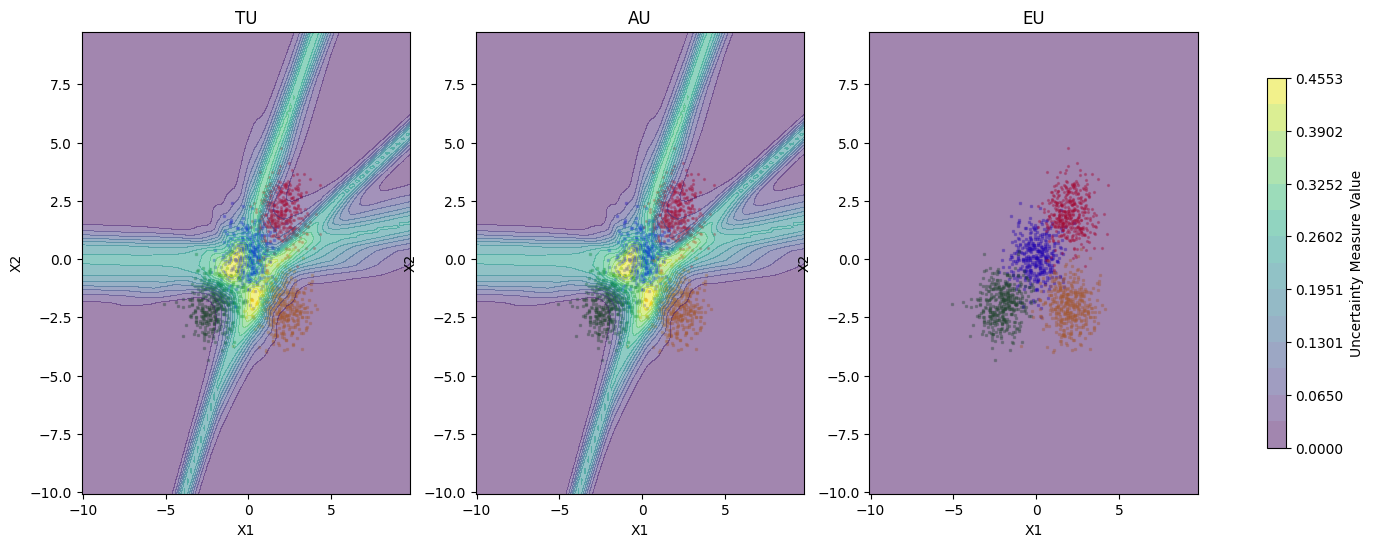

In [12]:
# Plot Aleatoric and Epistemic Uncertainty
from property_procedures.utils import visualize_au_eu_tu, ensemble_probs
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
visualize_au_eu_tu(
    fig,
    ensemble_model=base_ensmble,
    points=X,
    y_labels=y,
    axes=ax,
    multi_class=True
)

________________________________________


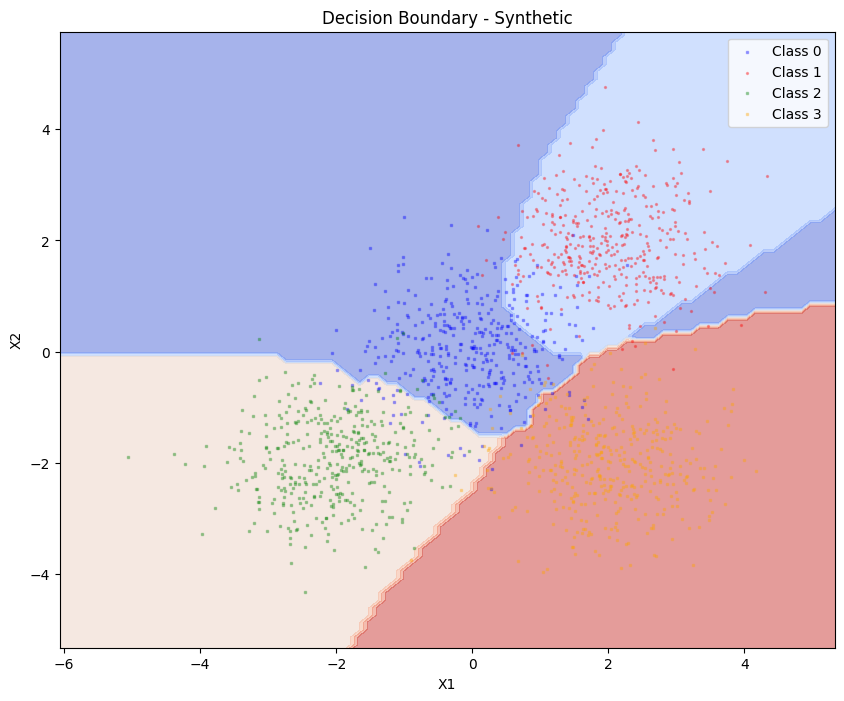

In [13]:
# Plot decision boundaries
from property_procedures.utils import visualize_decision_boundry
fig, ax = plt.subplots(figsize=(10, 8))

visualize_decision_boundry(
ax=ax,
points=X,
y_labels=y,
probability_function=ensemble_probs,
model=base_ensmble,
multi_class=True,
dataset_name="Synthetic"
)

In [14]:
point_to_explain = torch.tensor([[-2, -2]], dtype=torch.float32)
y_point_to_explain = base_ensmble.predict(point_to_explain)

In [15]:
from property_procedures.optimization import counter_factual_optimization_routine
from property_procedures.discriminative import discriminative_loss_function, discriminative_loss_function_2
from property_procedures.utils import aleatoric_uncertainty_ensemble, ensemble_probs, epistemic_uncertainty_ensemble

DESIRED_CLASS  = 0
MAX_STEPS = 10_000
LR =0.08
DESIRED_VALIDITY = 0.9
counter_factual, path = counter_factual_optimization_routine(
    point_to_explain=point_to_explain,
    model=base_ensmble,
    loss_function=discriminative_loss_function,
    probability_function=ensemble_probs,
    aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
    epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
    desired_class=DESIRED_CLASS,
    MAX_STEPS=MAX_STEPS,
    DESIRED_VALIDITY=DESIRED_VALIDITY,
    lr=LR,
    patience=MAX_STEPS,
    p_weight=1,
    lambda_1=1,
    lambda_2=1,
    delta=0.01,
    n_points=10,
    optimization_method="adam",
)
counter_factual_2, path_2 = counter_factual_optimization_routine(
    point_to_explain=point_to_explain,
    model=base_ensmble,
    loss_function=discriminative_loss_function_2,
    probability_function=ensemble_probs,
    aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
    epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
    desired_class=DESIRED_CLASS,
    MAX_STEPS=MAX_STEPS,
    DESIRED_VALIDITY=DESIRED_VALIDITY,
    lr=LR,
    patience=MAX_STEPS,
    p_weight=1,
    lambda_1=1,
    lambda_2=1,
    delta=0.01,
    n_points=10,
    optimization_method="adam",
)

Reached maximum number of steps.
Reached maximum number of steps.


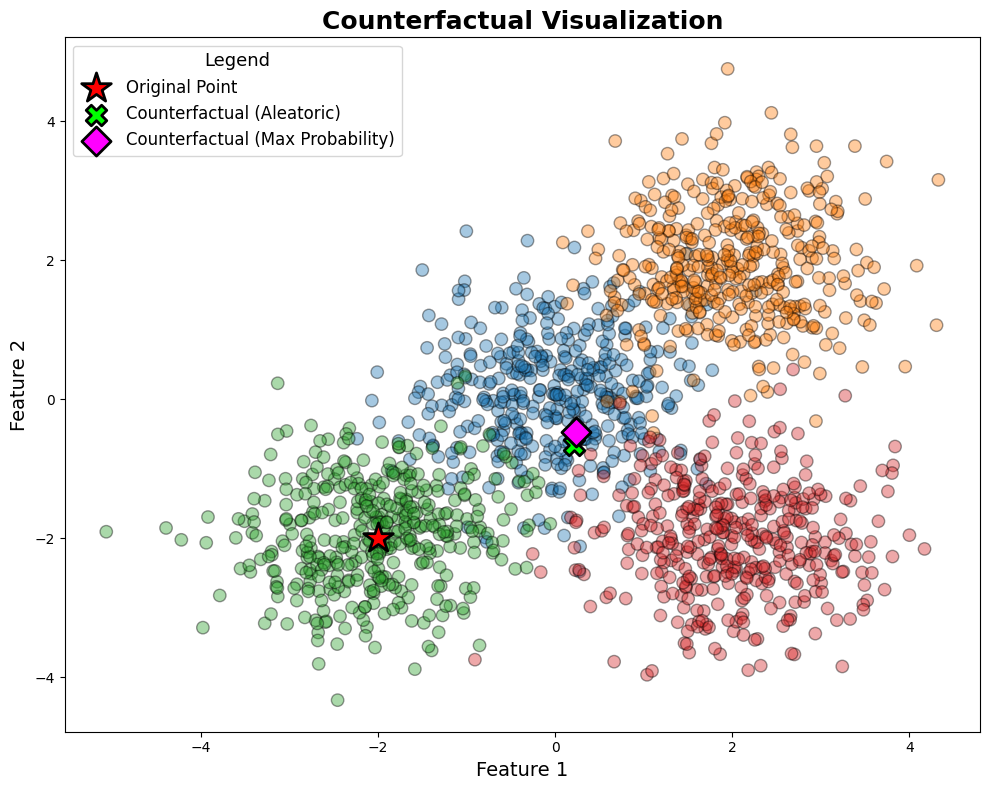

In [16]:
# visualize the counterfactuals with improved aesthetics
plt.figure(figsize=(10, 8))

# Define specific colors for each class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
color_map = [colors[int(label)] for label in y.numpy()]

plt.scatter(
    x=X[:, 0].numpy(),
    y=X[:, 1].numpy(),
    c=color_map,
    s=80,
    alpha=0.4,
    edgecolor='k',
)

# Original point
plt.scatter(
    point_to_explain[0, 0],
    point_to_explain[0, 1],
    color='red',
    s=500,
    marker='*',
    edgecolor='black',
    linewidth=2,
    label='Original Point'
)

# Counterfactual 1 (Aleatoric Uncertainty)
plt.scatter(
    counter_factual[0, 0],
    counter_factual[0, 1],
    color="lime",
    s=220,
    marker="X",
    edgecolor="black",
    linewidth=2,
    label="Counterfactual (Aleatoric)",
)

# Counterfactual 2 (Max Probability)
plt.scatter(
    counter_factual_2[0, 0],
    counter_factual_2[0, 1],
    color="magenta",
    s=220,
    marker="D",
    edgecolor="black",
    linewidth=2,
    label='Counterfactual (Max Probability)'
)

plt.title('Counterfactual Visualization', fontsize=18, fontweight='bold')
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.legend(title='Legend', fontsize=12, title_fontsize=13, loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('counterfactual_visualization.pdf', dpi=300)
plt.show()

In [17]:
y_prob_counterfactual = base_ensmble.predict(counter_factual)[0]
y_prob_counterfactual_2 = base_ensmble.predict(counter_factual_2)[0]
y_prob_counterfactual, y_prob_counterfactual_2

(tensor([[0.7731, 0.0522, 0.1081, 0.0666]], grad_fn=<CatBackward0>),
 tensor([[0.7625, 0.0755, 0.0808, 0.0812]], grad_fn=<CatBackward0>))